<a href="https://colab.research.google.com/github/vikranthrach/IIT-Patna--AI-and-ML-Course/blob/main/Batch2_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

In [ ]:
import pandas as pd
df = pd.read_csv("/content/used_cars_messy.csv")
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [ ]:
df.shape

(15661, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [ ]:
(df.isnull().sum() * 100) / len(df)

,0
Unnamed: 0,0.000000
car_name,0.000000
brand,0.000000
model,0.000000
vehicle_age,0.000000
km_driven,0.000000
seller_type,0.000000
fuel_type,0.000000
transmission_type,0.000000
mileage,8.205095


In [ ]:
df.duplicated().sum()

np.int64(169)

In [ ]:
df[df.duplicated(keep=False)].sort_values("car_name")

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4727,1809,Volkswagen Vento,Volkswagen,Vento,7,59000,Dealer,Petrol,Manual,15.04,1598.0,103.60,5.0,450000.0
9546,7646,Volkswagen Vento,Volkswagen,Vento,7,32000,Dealer,Diesel,Manual,NaN,1498.0,103.20,5.0,725000.0
10280,7646,Volkswagen Vento,Volkswagen,Vento,7,32000,Dealer,Diesel,Manual,NaN,1498.0,103.20,5.0,725000.0
911,18223,Volkswagen Vento,Volkswagen,Vento,10,69988,Dealer,Diesel,Manual,20.54,1598.0,103.60,5.0,349000.0


In [ ]:
169*2

338

In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,1.550300e+04
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,3.015072,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,0.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,1.000000e+09


In [ ]:
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [ ]:
cat_cols = ["brand", "seller_type", "fuel_type", "transmission_type"]

for cat in cat_cols:
    unique_vals = df[cat].unique()
    print(f"\n{cat} ({len(unique_vals)} unique Values)")
    print(sorted(unique_vals))


brand (80 unique Values)
[' Audi', ' Audi ', ' BMW', ' BMW ', ' Datsun', ' Datsun ', ' Ferrari ', ' Ford', ' Ford ', ' Honda', ' Honda ', ' Hyundai', ' Hyundai ', ' ISUZU ', ' Land Rover', ' MG ', ' Mahindra', ' Mahindra ', ' Maruti', ' Maruti ', ' Mercedes-AMG ', ' Mercedes-Benz ', ' Mini ', ' Nissan ', ' Porsche', ' Renault', ' Renault ', ' Skoda', ' Skoda ', ' Tata', ' Tata ', ' Toyota', ' Toyota ', ' Volkswagen', ' Volkswagen ', 'Audi', 'Audi ', 'BMW', 'BMW ', 'Bentley', 'Datsun', 'Datsun ', 'Force', 'Ford', 'Ford ', 'Honda', 'Honda ', 'Hyundai', 'Hyundai ', 'ISUZU', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Mahindra ', 'Maruti', 'Maruti ', 'Maserati', 'Mercedes-Benz', 'Mercedes-Benz ', 'Mini', 'Nissan', 'Porsche', 'Renault', 'Renault ', 'Rolls-Royce', 'Skoda', 'Skoda ', 'Tata', 'Tata ', 'Toyota', 'Toyota ', 'Volkswagen', 'Volkswagen ', 'Volvo', 'Volvo ']

seller_type (9 unique Values)
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 'I

In [ ]:
df['km_driven'].dtype

dtype('O')

In [ ]:
df[df['km_driven'] == "67647"]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.8,5.0,575000.0


In [ ]:
df['km_driven'].sample(50).tolist()

['33000',
 '17745',
 '70000',
 '13500',
 '34890',
 '60000',
 '55000',
 '67000',
 '95000',
 '170000',
 '50000',
 '80000',
 '33000',
 '66733',
 '21800',
 '30000',
 '18000',
 '25000',
 '37962',
 '34293',
 '135000',
 '5000',
 '140000',
 '4500',
 '70000',
 '40000',
 '10000',
 '15200',
 '67000',
 '75000',
 '57000',
 '30000',
 '25000',
 '40000',
 '25000',
 '71500',
 '20,000',
 '50000',
 '95000',
 '26000',
 '70000',
 '75000',
 '29945',
 '24000',
 '35000',
 '85000',
 '31000',
 '37000',
 '5000',
 '47000']

In [ ]:
df['mileage'].dtype

dtype('O')

In [ ]:
df['mileage'].sample(200).tolist()

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
df['selling_price'].describe()

,selling_price
count,15503.0000
mean,1032763.7793
std,16073797.4950
min,500.0000
25%,385000.0000
50%,555000.0000
75%,825000.0000
max,999999999.0000


# Drop the Useless Columns

In [ ]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type',
       'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price'],
      dtype='object')

In [ ]:
df = df.drop(columns = ['Unnamed: 0'])
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type',
       'mileage', 'engine', 'max_power', 'seats', 'selling_price'],
      dtype='object')

# Fix the Brand Names

In [ ]:
print(f"Unique values before cleaning {df['brand'].nunique()}")

df['brand'] = df['brand'].str.strip()

print(f"Unique values After cleaning {df['brand'].nunique()}")

df['brand'].value_counts().head(10)


Unique values before cleaning 80
Unique values After cleaning 32


,count
brand,
Maruti,5077
Hyundai,3025
Honda,1508
Mahindra,1031
Toyota,806
Ford,802
Volkswagen,634
Renault,550
BMW,443


In [ ]:
# TODO - Comvert this into lower

# Fix the fuel type

petrol --- Petrol
DIESEL --- Diesel

In [ ]:
print(f"Unique values before cleaning {df['fuel_type'].nunique()}")
df['fuel_type'] = df['fuel_type'].str.strip().str.title()
print(f"Unique values after cleaning {df['fuel_type'].nunique()}")
df['fuel_type'].value_counts().head(10)

Unique values before cleaning 14
Unique values after cleaning 5


,count
fuel_type,
Petrol,7765
Diesel,7544
Cng,302
Lpg,46
Electric,4


# Fix the Seller Type

In [ ]:
df['seller_type'].unique()

array(['Dealer', 'dealer', 'Individual', 'individual', 'DEALER',
       'Trustmark Dealer', 'Individul', 'Individuall', 'Delaer'],
      dtype=object)

In [ ]:
print(f"Unique values before cleaning {df['seller_type'].nunique()}")

df['seller_type'] = df['seller_type'].str.strip().str.title()

print(f"Unique values after cleaning {df['seller_type'].nunique()}")

# Create a dictiorny

# Step 2: Fix remaining typos with a mapping
typo_map = {
    'Individul': 'Individual',
    'Individuall': 'Individual',
    'Delaer': 'Dealer',
    'Trustmark Delaer': 'Trustmark Dealer'
}

df['seller_type'] = df['seller_type'].replace(typo_map)
print(f"Final Unique values after cleaning {df['seller_type'].nunique()}")
print(df['seller_type'].value_counts())

Unique values before cleaning 9
Unique values after cleaning 6
Final Unique values after cleaning 3
seller_type
Dealer              9694
Individual          5792
Trustmark Dealer     175
Name: count, dtype: int64


# Fix Numeric Columns with String Issues

In [ ]:
df['km_driven'].sample(100).tolist()

In [ ]:
df['km_driven'] = df['km_driven'].astype(str)
df['km_driven'] = df['km_driven'].str.replace(",", "")
df['km_driven'] = df['km_driven'].str.replace("kms", "")
df['km_driven'] = df['km_driven'].str.replace("km", "")
df['km_driven'] = df['km_driven'].str.strip()
df['km_driven'] = pd.to_numeric(df['km_driven'], errors = 'coerce')
df['km_driven'].sample(100)

,km_driven
5537,11799
14213,125000
10375,89000
558,56000
3481,23000
656,61996
8996,15000
6995,75000
1461,43000
13716,53123


# Fix for milleage

In [ ]:
df['mileage'] = df['mileage'].astype(str).replace("kmpl", "")
df['mileage'] = df['mileage'].str.strip()
df['mileage'] = pd.to_numeric(df['mileage'], errors = 'coerce')
df['mileage'].sample(100)

,mileage
11857,21.1400
1303,27.6200
5400,18.9000
3112,23.4000
14468,27.3000
7710,24.3000
6112,23.8400
10345,21.7000
6538,22.0700
1258,19.7000


# Handling Missing Values

In [ ]:
df.loc[3,"km_driven"]

np.int64(82000)

In [ ]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1485
engine,1869


In [ ]:
before = len(df)

df = df.dropna(subset=['selling_price'])
after = len(df)

print(f"Dropped {before -after} rows where selling_price was missing")
print(f"remaining rows {after}")

Dropped 158 rows where selling_price was missing
remaining rows 15503


In [ ]:
for col in ["engine", "mileage", "max_power"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"filled {col} missing vlaues with median: {median_val}")

filled engine missing vlaues with median: 1248.0
filled mileage missing vlaues with median: 19.67
filled max_power missing vlaues with median: 88.5


In [ ]:
seats_mode = df['seats'].mode()[0]
df["seats"] = df["seats"].fillna(seats_mode)
print(f"filled seats missing vlaues with mode: {seats_mode}")

filled seats missing vlaues with mode: 5.0


In [ ]:
df.duplicated().sum()

np.int64(291)

In [ ]:
df = df.drop_duplicates()

# Df desribe

In [ ]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000
mean,6.0379,55611.7656,19.6858,1452.9972,99.9624,5.3151,1038508.0115
std,3.0161,51839.7243,3.9685,486.3077,41.8938,0.7972,16226444.0022
min,0.0000,100.0000,4.0000,793.0000,38.4000,0.0000,500.0000
25%,4.0000,30000.0000,17.1000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,555000.0000
75%,8.0000,70000.0000,22.3000,1498.0000,113.4200,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,999999999.0000


# Outliers

Text(0, 0.5, 'Price (₹)')

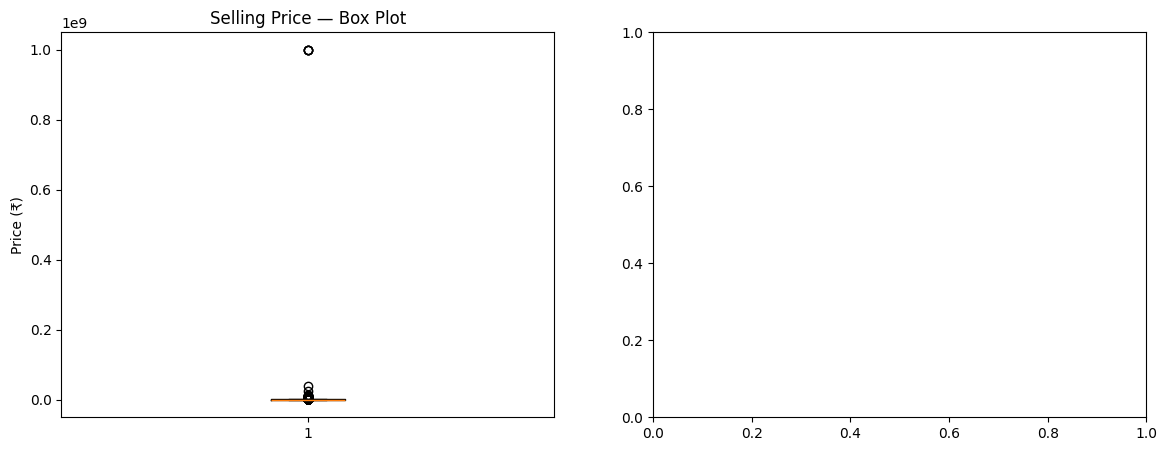

In [ ]:
# Visualize outliers in selling_price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')


In [ ]:
before = len(df)

df = df[df['selling_price'] != 999999999]
df = df[df["selling_price"]>10000]
df = df[df["seats"]>0]

after = len(df)


print(before, after)

15212 15202


In [ ]:
df[df['vehicle_age'] == '15152']

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [ ]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.8700,1461.0000,83.8000,5.0000,575000.0000
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,Cng,Manual,33.5400,998.0000,67.0400,5.0000,435000.0000
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,19.6700,1497.0000,117.6000,5.0000,875000.0000
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,Diesel,Manual,15.4000,2179.0000,88.5000,8.0000,925000.0000
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0000,2179.0000,140.0000,7.0000,1175000.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.7700,1248.0000,88.8000,7.0000,665000.0000
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.0900,1248.0000,103.2000,5.0000,249000.0000
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.5100,998.0000,67.0400,5.0000,250000.0000
15659,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6000,1197.0000,81.8600,5.0000,620000.0000


In [ ]:
# Method 1: Simple map (recommended for binary)
df['transmission_type'] = df['transmission_type'].map({'Manual': 0, 'Automatic': 1})

df['transmission_type']


,transmission_type
0,0
1,0
2,0
3,0
4,1
...,...
15656,0
15657,0
15658,0
15659,0
